In [10]:
# Import Library
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
from scipy import stats

In [11]:
# Load CSV into dataframes
import pandas as pd
appearances = pd.read_csv(r"C:\Users\payal\Downloads\football data analysis csv\appearances.csv")
print(appearances)
print(appearances.head())
players = pd.read_csv(r"C:\Users\payal\Downloads\football data analysis csv\players.csv")
print(players)
print(players.head())
games = pd.read_csv(r"C:\Users\payal\Downloads\football data analysis csv\games.csv")
print(games)
print(games.head())

          appearance_id  game_id  player_id  player_club_id  \
0         2231978_38004  2231978      38004             853   
1         2233748_79232  2233748      79232            8841   
2         2234413_42792  2234413      42792            6251   
3         2234418_73333  2234418      73333            1274   
4        2234421_122011  2234421     122011             195   
...                 ...      ...        ...             ...   
1638440  4506874_670681  4506874     670681             583   
1638441  4506874_687626  4506874     687626             631   
1638442  4506874_708265  4506874     708265             583   
1638443  4506874_743600  4506874     743600             631   
1638444  4506874_872171  4506874     872171             583   

         player_current_club_id        date       player_name competition_id  \
0                           235  2012-07-03  Aurélien Joachim            CLQ   
1                          2698  2012-07-05    Ruslan Abyshov            ELQ   
2  

In [12]:
# Merge appearances,players, and games dataframes
full_players_info = players.merge(appearances, on='player_id')
full_players_info = full_players_info.merge(games[['game_id','season']], on='game_id') 
# Combining games dataframe but we only took the season columns from it (those are the only information we needed)

# Since our focus mainly on market value of the players, we will sort the dataframe for players with highest market value first go get better sense of it
full_players_info = full_players_info.sort_values(by='market_value_in_eur', ascending=False)

In [13]:
# Display our dataframe after the merging of three dataframe
full_players_info

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played,season
1435017,418560,Erling,Haaland,Erling Haaland,2024,281,erling-haaland,England,Leeds,Norway,...,281,2021-01-16,Erling Haaland,L1,0,0,0,0,90,2020
1435018,418560,Erling,Haaland,Erling Haaland,2024,281,erling-haaland,England,Leeds,Norway,...,281,2021-01-19,Erling Haaland,L1,0,0,0,0,90,2020
1435019,418560,Erling,Haaland,Erling Haaland,2024,281,erling-haaland,England,Leeds,Norway,...,281,2021-01-22,Erling Haaland,L1,0,0,2,0,90,2020
1434988,418560,Erling,Haaland,Erling Haaland,2024,281,erling-haaland,England,Leeds,Norway,...,281,2020-02-14,Erling Haaland,L1,0,0,1,0,79,2019
1434989,418560,Erling,Haaland,Erling Haaland,2024,281,erling-haaland,England,Leeds,Norway,...,281,2020-02-18,Erling Haaland,CL,0,0,2,0,90,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638392,1293592,Davyd,Blagodarnyi,Davyd Blagodarnyi,2024,63007,davyd-blagodarnyi,Ukraine,Dnipropetrovsk,Ukraine,...,63007,2025-05-25,Davyd Blagodarnyi,UKR1,0,0,0,0,9,2024
1638406,1298615,Tymerlan,Grygorchuk,Tymerlan Grygorchuk,2024,6992,tymerlan-grygorchuk,NaN,NaN,Ukraine,...,6992,2024-08-21,Tymerlan Grygorchuk,UKRP,0,0,0,0,4,2024
1638424,1381775,Anton,Vydrych,Anton Vydrych,2024,26459,anton-vydrych,Ukraine,"Boratyn, Volyn Oblast",Ukraine,...,26459,2025-04-02,Anton Vydrych,UKRP,0,0,0,0,10,2024
1638436,1397259,Abdurrahman Burak,Sayin,Abdurrahman Burak Sayin,2024,385,abdurrahman-burak-sayin,NaN,NaN,Netherlands,...,385,2025-04-12,Abdurrahman Burak Sayin,NL1,0,0,0,0,3,2024


In [14]:
# See our central dataframe shape
print("shape of the dataset (rows, columns):")

full_players_info.shape


shape of the dataset (rows, columns):


(1638439, 36)

In [15]:
print("data summary")
print(full_players_info.info())

data summary
<class 'pandas.DataFrame'>
Index: 1638439 entries, 1435017 to 1638437
Data columns (total 36 columns):
 #   Column                                Non-Null Count    Dtype  
---  ------                                --------------    -----  
 0   player_id                             1638439 non-null  int64  
 1   first_name                            1513246 non-null  str    
 2   last_name                             1638439 non-null  str    
 3   name                                  1638439 non-null  str    
 4   last_season                           1638439 non-null  int64  
 5   current_club_id                       1638439 non-null  int64  
 6   player_code                           1638439 non-null  str    
 7   country_of_birth                      1598051 non-null  str    
 8   city_of_birth                         1621445 non-null  str    
 9   country_of_citizenship                1614906 non-null  str    
 10  date_of_birth                         1637474 non-n

In [16]:
print("Stats summary")
print(full_players_info.describe())


Stats summary
          player_id   last_season  current_club_id  height_in_cm  \
count  1.638439e+06  1.638439e+06     1.638439e+06  1.622571e+06   
mean   2.000740e+05  2.021158e+03     3.770582e+03  1.821530e+02   
std    1.855221e+05  3.169348e+00     1.001300e+04  6.611429e+00   
min    1.000000e+01  2.012000e+03     3.000000e+00  1.800000e+01   
25%    5.718800e+04  2.019000e+03     3.360000e+02  1.780000e+02   
50%    1.405790e+05  2.023000e+03     9.030000e+02  1.820000e+02   
75%    2.898140e+05  2.024000e+03     2.687000e+03  1.870000e+02   
max    1.411351e+06  2.024000e+03     1.103020e+05  2.070000e+02   

       market_value_in_eur  highest_market_value_in_eur       game_id  \
count         1.637896e+06                 1.637896e+06  1.638439e+06   
mean          4.003292e+06                 1.239548e+07  3.114903e+06   
std           1.126433e+07                 2.003709e+07  6.287674e+05   
min           1.000000e+04                 1.000000e+04  2.211607e+06   
25%     

In [17]:
# There are irrelevant column because it's not our main focus for analysis, these redundant columns will be dropped
columns_to_drop = ['highest_market_value_in_eur','country_of_birth','last_season','contract_expiration_date','player_name', 
                    'agent_name' ,'appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'competition_id', 
                    'first_name', 'last_name', 'current_club_id', 'player_code', 'city_of_birth', 'sub_position', 'image_url', 'url', 'date']

# Dropping those columns
full_players_info = full_players_info.drop(columns=columns_to_drop)

In [18]:
print(full_players_info)


                            name country_of_citizenship        date_of_birth  \
1435017           Erling Haaland                 Norway  2000-07-21 00:00:00   
1435018           Erling Haaland                 Norway  2000-07-21 00:00:00   
1435019           Erling Haaland                 Norway  2000-07-21 00:00:00   
1434988           Erling Haaland                 Norway  2000-07-21 00:00:00   
1434989           Erling Haaland                 Norway  2000-07-21 00:00:00   
...                          ...                    ...                  ...   
1638392        Davyd Blagodarnyi                Ukraine  2006-07-27 00:00:00   
1638406      Tymerlan Grygorchuk                Ukraine  2008-01-02 00:00:00   
1638424            Anton Vydrych                Ukraine  2008-01-30 00:00:00   
1638436  Abdurrahman Burak Sayin            Netherlands  2006-08-23 00:00:00   
1638437          Beytullah Gezer                Türkiye  2010-05-26 00:00:00   

         position   foot  height_in_cm 

In [19]:
# Filter rows for players data on season 23/24
full_players_info_2023 = full_players_info.loc[full_players_info['season'] == 2023]

# Drop the 'season' column because we doesn't need it anymore (we already extracted the information needed)
full_players_info_2023 = full_players_info_2023.drop('season', axis=1)
# Show the first 5 rows of our dataframe after filtering
full_players_info_2023.head()



,name,country_of_citizenship,date_of_birth,position,foot,height_in_cm,current_club_domestic_competition_id,current_club_name,market_value_in_eur,yellow_cards,red_cards,goals,assists,minutes_played
1435129,Erling Haaland,Norway,2000-07-21 00:00:00,Attack,left,195.0,GB1,Manchester City Football Club,200000000.0,0,0,1,0,90
1435130,Erling Haaland,Norway,2000-07-21 00:00:00,Attack,left,195.0,GB1,Manchester City Football Club,200000000.0,0,0,0,1,90
1435131,Erling Haaland,Norway,2000-07-21 00:00:00,Attack,left,195.0,GB1,Manchester City Football Club,200000000.0,0,0,1,0,90
1435145,Erling Haaland,Norway,2000-07-21 00:00:00,Attack,left,195.0,GB1,Manchester City Football Club,200000000.0,0,0,0,0,19
1435146,Erling Haaland,Norway,2000-07-21 00:00:00,Attack,left,195.0,GB1,Manchester City Football Club,200000000.0,0,0,0,1,86


In [20]:
full_players_info_2023.tail()

,name,country_of_citizenship,date_of_birth,position,foot,height_in_cm,current_club_domestic_competition_id,current_club_name,market_value_in_eur,yellow_cards,red_cards,goals,assists,minutes_played
1638348,Vladyslav Kramar,Ukraine,2005-12-06 00:00:00,Midfield,right,185.0,UKR1,FK Polissya Zhytomyr,NaN,0,0,0,0,1
1638349,Ahmet Mert Koşar,Türkiye,2006-11-29 00:00:00,Attack,right,189.0,TR1,Pendikspor,NaN,0,0,0,0,1
1638360,Bünyamin Çetinkaya,Türkiye,2009-09-08 00:00:00,Attack,NaN,NaN,TR1,Kasımpaşa A.Ş.,NaN,0,0,0,0,1
1638361,Sjors-Lowis Hermsen,Netherlands,2006-06-12 00:00:00,Missing,NaN,175.0,NL1,Fortuna Sittardia Combinatie,NaN,0,0,0,0,1
1638368,Tymur Butenko,Ukraine,2006-11-14 00:00:00,Attack,right,174.0,UKR1,FK Kryvbas Kryvyi Rig,NaN,0,0,0,0,9


In [23]:
# Group by player name and sum the relevant columns (we want to count the total statistics for season 23/24 for each players)
player_stats_2023 = full_players_info_2023.groupby('name').agg({
    'yellow_cards': 'sum', # Count the total yellow_cards that player received in season 23/24
    'red_cards': 'sum', # Count the total red_cards that player received in season 23/24
    'goals': 'sum', # Do the same process as above
    'assists': 'sum', # Do the same process as above
    'minutes_played': 'sum' # Do the same process as above
})

# Reset the index to make 'name' a regular column
player_stats_2023 = player_stats_2023.reset_index()

# Display player_stats_2023 dataframe
player_stats_2023


,name,yellow_cards,red_cards,goals,assists,minutes_played
0,Aaron Appindangoyé,31,0,31,62,83328
1,Aaron Brown,0,0,0,0,1
2,Aaron Cresswell,54,0,18,0,16704
3,Aaron Donnelly,34,0,0,34,23052
4,Aaron Hickey,45,0,0,0,6480
...,...,...,...,...,...,...
7100,İsmail Çokçalış,0,0,0,14,15078
7101,İzzet Topatar,2,0,0,0,78
7102,İzzet Çelik,0,0,0,0,220
7103,Şamil Öztürk,0,0,0,0,1


In [26]:
# Drop the original columns from the central DataFrame because we have the total stats now
full_players_info_2023.drop(columns=['yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played'], inplace=True)

# Merge between player total stats 
full_players_info_2023 = full_players_info_2023.merge(player_stats_2023, how='left', on='name')

In [27]:
# Print how many duplicate values we have
print("Number of duplicate values :",full_players_info_2023.duplicated().sum())

Number of duplicate values : 135562


In [30]:
# Drop the duplicates columns again because we merged between dataframes
full_players_info_2023 = full_players_info_2023.drop_duplicates()


In [29]:
# Show the current dataframe after dropping the duplicates
full_players_info_2023

,name,country_of_citizenship,date_of_birth,position,foot,height_in_cm,current_club_domestic_competition_id,current_club_name,market_value_in_eur,yellow_cards,red_cards,goals,assists,minutes_played
0,Erling Haaland,Norway,2000-07-21 00:00:00,Attack,left,195.0,GB1,Manchester City Football Club,200000000.0,45,0,1710,225,168525
45,Kylian Mbappé,France,1998-12-20 00:00:00,Attack,right,178.0,FR1,Paris Saint-Germain Football Club,180000000.0,210,0,1512,294,139818
81,Vinicius Junior,Brazil,2000-07-12 00:00:00,Attack,right,176.0,ES1,Real Madrid Club de Fútbol,180000000.0,429,0,936,429,120276
126,Jude Bellingham,England,2003-06-29 00:00:00,Midfield,right,186.0,ES1,Real Madrid Club de Fútbol,160000000.0,378,42,966,546,153048
168,Phil Foden,England,2000-05-28 00:00:00,Attack,left,171.0,GB1,Manchester City Football Club,150000000.0,156,0,1404,624,221468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142709,Vladyslav Kramar,Ukraine,2005-12-06 00:00:00,Midfield,right,185.0,UKR1,FK Polissya Zhytomyr,NaN,0,0,0,0,4
142711,Ahmet Mert Koşar,Türkiye,2006-11-29 00:00:00,Attack,right,189.0,TR1,Pendikspor,NaN,0,0,0,0,1
142712,Bünyamin Çetinkaya,Türkiye,2009-09-08 00:00:00,Attack,NaN,NaN,TR1,Kasımpaşa A.Ş.,NaN,0,0,0,0,1
142713,Sjors-Lowis Hermsen,Netherlands,2006-06-12 00:00:00,Missing,NaN,175.0,NL1,Fortuna Sittardia Combinatie,NaN,0,0,0,0,1


In [31]:
# Reset the dataframe index to make it more managable
full_players_info_2023 = full_players_info_2023.reset_index()
full_players_info_2023 = full_players_info_2023.drop(columns='index')

# Display the dataframe
full_players_info_2023.head(10)

,name,country_of_citizenship,date_of_birth,position,foot,height_in_cm,current_club_domestic_competition_id,current_club_name,market_value_in_eur,yellow_cards,red_cards,goals,assists,minutes_played
0,Erling Haaland,Norway,2000-07-21 00:00:00,Attack,left,195.0,GB1,Manchester City Football Club,200000000.0,45,0,1710,225,168525
1,Kylian Mbappé,France,1998-12-20 00:00:00,Attack,right,178.0,FR1,Paris Saint-Germain Football Club,180000000.0,210,0,1512,294,139818
2,Vinicius Junior,Brazil,2000-07-12 00:00:00,Attack,right,176.0,ES1,Real Madrid Club de Fútbol,180000000.0,429,0,936,429,120276
3,Jude Bellingham,England,2003-06-29 00:00:00,Midfield,right,186.0,ES1,Real Madrid Club de Fútbol,160000000.0,378,42,966,546,153048
4,Phil Foden,England,2000-05-28 00:00:00,Attack,left,171.0,GB1,Manchester City Football Club,150000000.0,156,0,1404,624,221468
5,Bukayo Saka,England,2001-09-05 00:00:00,Attack,left,178.0,GB1,Arsenal Football Club,130000000.0,184,0,920,644,176686
6,Jamal Musiala,Germany,2003-02-26 00:00:00,Midfield,right,184.0,L1,FC Bayern München,130000000.0,114,0,456,304,108680
7,Michael Olise,France,2001-12-12 00:00:00,Attack,left,184.0,L1,FC Bayern München,130000000.0,0,0,190,114,24282
8,Declan Rice,England,1999-01-14 00:00:00,Midfield,right,188.0,GB1,Arsenal Football Club,120000000.0,350,0,350,500,212050
9,Cole Palmer,England,2002-05-06 00:00:00,Midfield,left,185.0,GB1,Chelsea Football Club,120000000.0,294,0,1050,546,133644


In [32]:
full_players_info_2023.columns

Index(['name', 'country_of_citizenship', 'date_of_birth', 'position', 'foot',
       'height_in_cm', 'current_club_domestic_competition_id',
       'current_club_name', 'market_value_in_eur', 'yellow_cards', 'red_cards',
       'goals', 'assists', 'minutes_played'],
      dtype='str')

In [33]:
# Transform date_of_birth into datetime format
full_players_info_2023['date_of_birth'] = pd.to_datetime(full_players_info_2023['date_of_birth'])

In [34]:
# Get the current datetime
now = datetime.now()

In [38]:
full_players_info_2023.head(10)

,name,country_of_citizenship,date_of_birth,position,foot,height_in_cm,current_club_domestic_competition_id,current_club_name,market_value_in_eur,yellow_cards,red_cards,goals,assists,minutes_played,age
0,Erling Haaland,Norway,2000-07-21,Attack,left,195.0,GB1,Manchester City Football Club,200000000.0,45,0,1710,225,168525,25.659138
1,Kylian Mbappé,France,1998-12-20,Attack,right,178.0,FR1,Paris Saint-Germain Football Club,180000000.0,210,0,1512,294,139818,27.244353
2,Vinicius Junior,Brazil,2000-07-12,Attack,right,176.0,ES1,Real Madrid Club de Fútbol,180000000.0,429,0,936,429,120276,25.683778
3,Jude Bellingham,England,2003-06-29,Midfield,right,186.0,ES1,Real Madrid Club de Fútbol,160000000.0,378,42,966,546,153048,22.721424
4,Phil Foden,England,2000-05-28,Attack,left,171.0,GB1,Manchester City Football Club,150000000.0,156,0,1404,624,221468,25.806982
5,Bukayo Saka,England,2001-09-05,Attack,left,178.0,GB1,Arsenal Football Club,130000000.0,184,0,920,644,176686,24.533881
6,Jamal Musiala,Germany,2003-02-26,Midfield,right,184.0,L1,FC Bayern München,130000000.0,114,0,456,304,108680,23.058179
7,Michael Olise,France,2001-12-12,Attack,left,184.0,L1,FC Bayern München,130000000.0,0,0,190,114,24282,24.265572
8,Declan Rice,England,1999-01-14,Midfield,right,188.0,GB1,Arsenal Football Club,120000000.0,350,0,350,500,212050,27.175907
9,Cole Palmer,England,2002-05-06,Midfield,left,185.0,GB1,Chelsea Football Club,120000000.0,294,0,1050,546,133644,23.868583


In [43]:
# Calculate age in years

full_players_info_2023['date_of_birth'] = pd.to_datetime(full_players_info_2023['date_of_birth'])





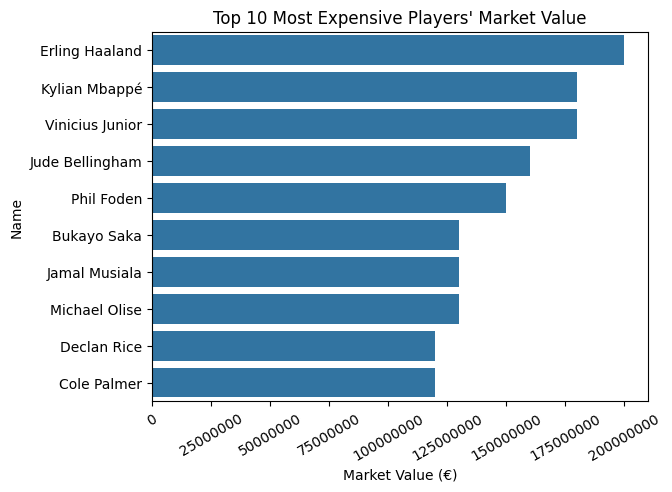

In [44]:
# Filter the DataFrame, sort it by 'market_value_in_eur', and select the top 10 players
sns.barplot(data=full_players_info_2023.sort_values(by='market_value_in_eur', ascending=False).head(10), x='market_value_in_eur', y='name', edgecolor="none")

# Define the format function
def format_func(value, tick_number):
    return f'{value:.0f}'

# Plot the data
pvl = plt.gca()

# Apply the format to x-axis
pvl.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
# Set the label and titles
plt.xlabel('Market Value (€)')
plt.xticks(rotation=30)
plt.ylabel('Name')
plt.title("Top 10 Most Expensive Players' Market Value")

# Show the plot
plt.show()

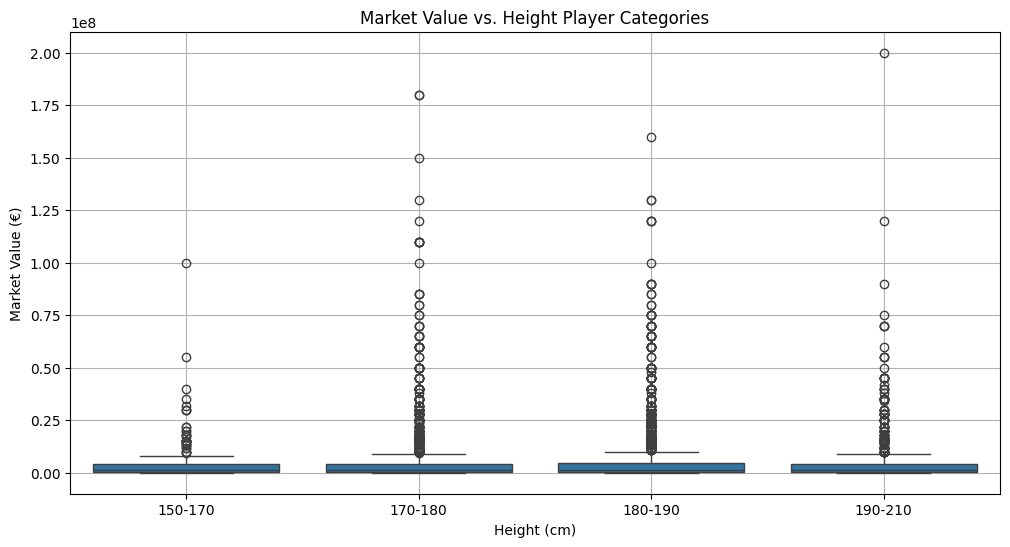

In [45]:
# Create a temporary copy of the DataFrame to avoid modifying the original
df_copy = full_players_info_2023.copy()

# Define height bins and labels
bins_height = [150, 170, 180, 190, 210]
labels_height = ['150-170', '170-180', '180-190', '190-210']

# Create height categories in the copy of the DataFrame
df_copy['height_category'] = pd.cut(df_copy['height_in_cm'], bins=bins_height, labels=labels_height)

# Box plot for market value vs. height categories
plt.figure(figsize=(12, 6))
sns.boxplot(x='height_category', y='market_value_in_eur', data=df_copy)
plt.xlabel('Height (cm)')
plt.ylabel('Market Value (€)')
plt.title('Market Value vs. Height Player Categories')
plt.grid(True)
plt.show()

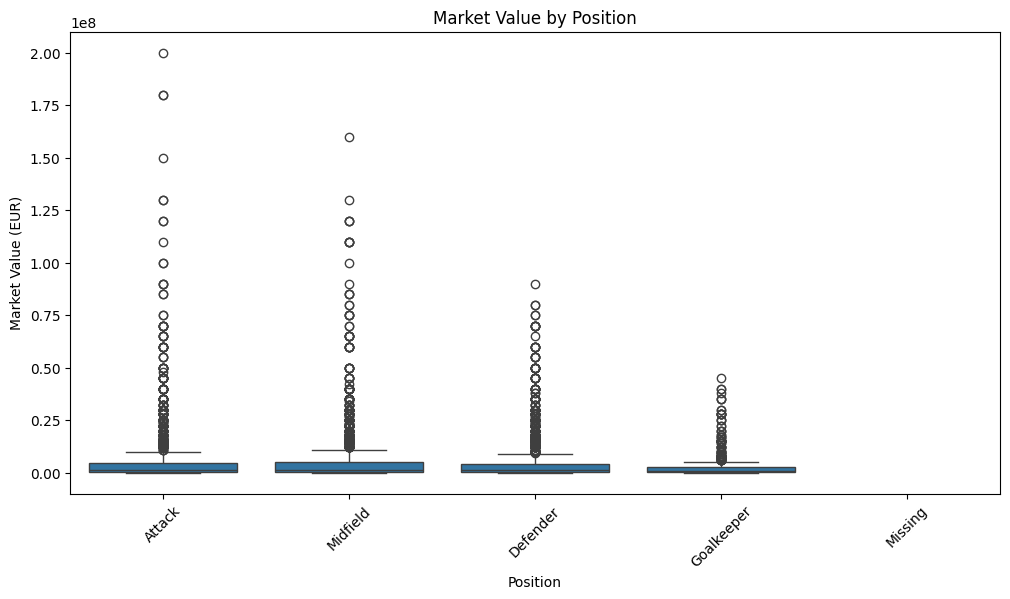

In [46]:
# Box plot: Market Value by Position
plt.figure(figsize=(12, 6))
sns.boxplot(x='position', y='market_value_in_eur', data=full_players_info_2023)
plt.title('Market Value by Position')
plt.xlabel('Position')
plt.ylabel('Market Value (EUR)')
plt.xticks(rotation=45)
plt.show()

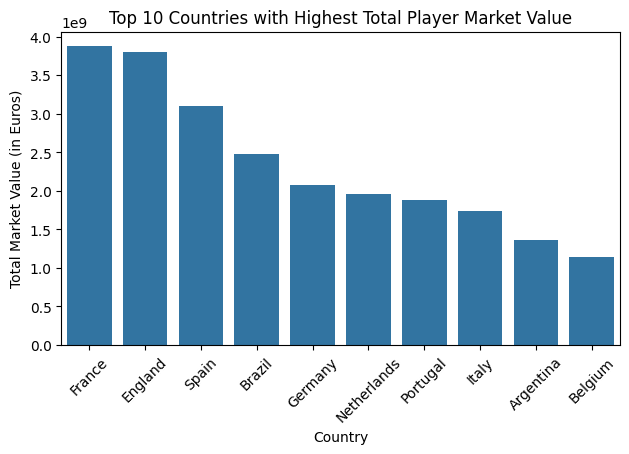

In [47]:
# Group by country and calculate the sum of market values
country_market_value = full_players_info_2023.groupby('country_of_citizenship')['market_value_in_eur'].sum().sort_values(ascending=False)

# Select top 10 countries
top_10_countries = country_market_value.head(10)

# Create a bar chart with seaborn
sns.barplot(x=top_10_countries.index, y=top_10_countries.values)
# Customize the plot with labels and title
plt.xlabel('Country')
plt.ylabel('Total Market Value (in Euros)')
plt.xticks(rotation=45)
plt.title('Top 10 Countries with Highest Total Player Market Value')
plt.tight_layout()  # Adjust spacing between elements for better readability

# Show the plot
plt.show()


<Figure size 1000x600 with 0 Axes>

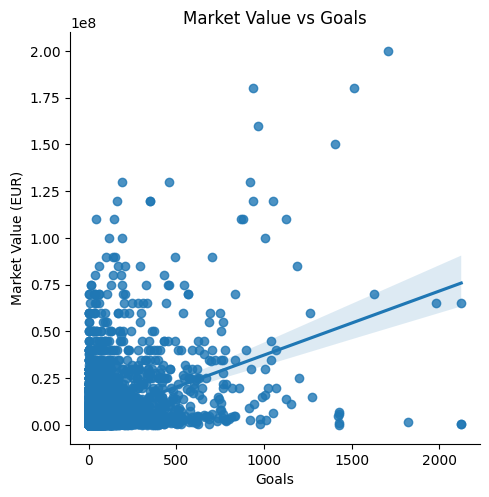

In [48]:
# Scatter plot: Market Value vs Goals
plt.figure(figsize=(10, 6))
sns.lmplot(x='goals', y='market_value_in_eur', data=full_players_info_2023)
plt.title('Market Value vs Goals')
plt.xlabel('Goals')
plt.ylabel('Market Value (EUR)')
plt.show()

<Figure size 1000x600 with 0 Axes>

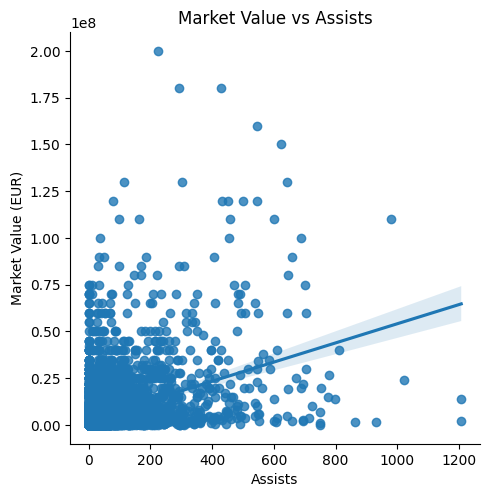

In [49]:
# Scatter plot: Market Value vs Assists
plt.figure(figsize=(10, 6))
sns.lmplot(x='assists', y='market_value_in_eur', data=full_players_info_2023)
plt.title('Market Value vs Assists')
plt.xlabel('Assists')
plt.ylabel('Market Value (EUR)')
plt.show()

<Figure size 1000x600 with 0 Axes>

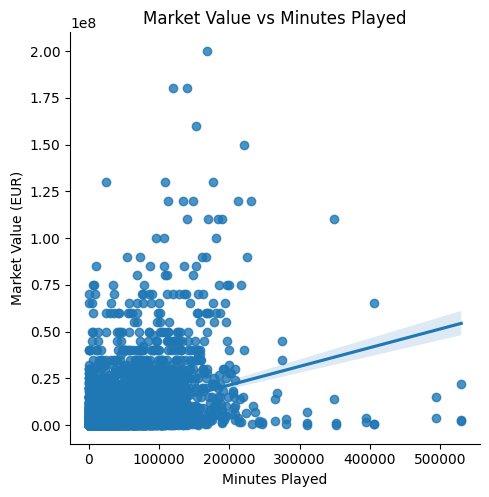

In [50]:
# Scatter plot: Market Value vs Minutes Played
plt.figure(figsize=(10, 6))
sns.lmplot(x='minutes_played', y='market_value_in_eur', data=full_players_info_2023)
plt.title('Market Value vs Minutes Played')
plt.xlabel('Minutes Played')
plt.ylabel('Market Value (EUR)')
plt.show()

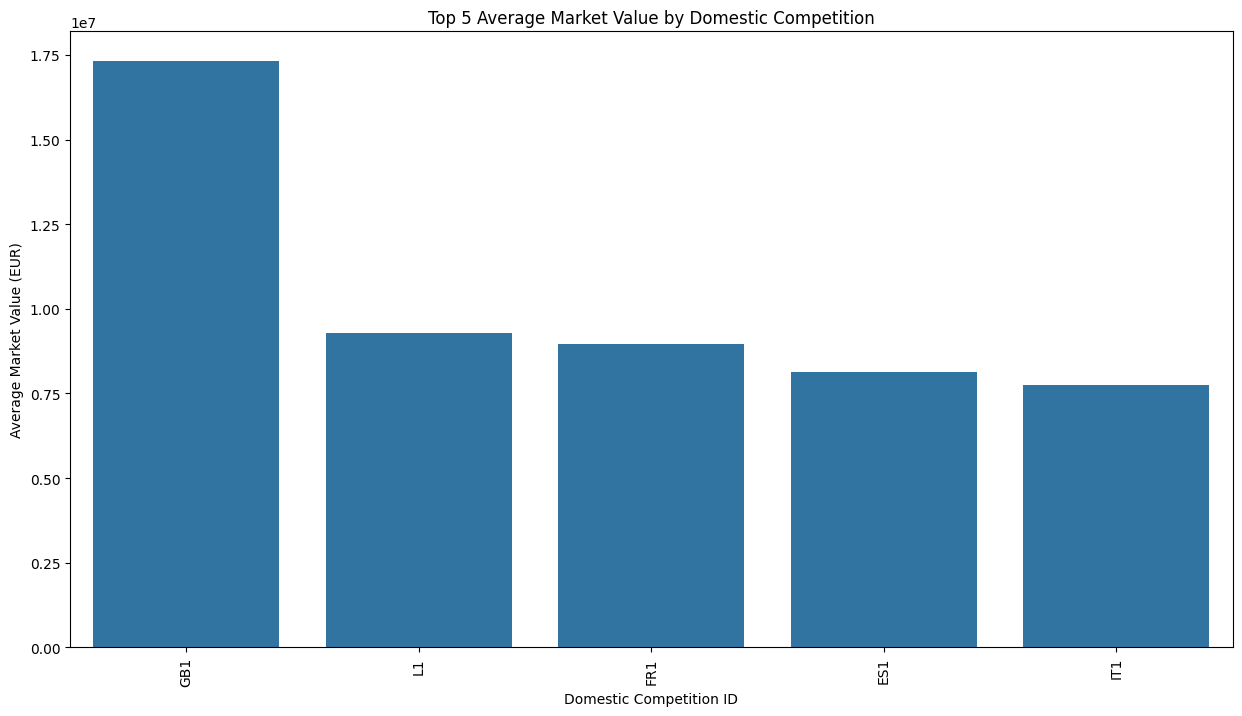

In [51]:
# Bar plot: Market Value by League
plt.figure(figsize=(15, 8))
avg_market_value_by_competition = full_players_info_2023.groupby('current_club_domestic_competition_id')['market_value_in_eur'].mean().sort_values(ascending=False).head(5)
sns.barplot(x=avg_market_value_by_competition.index, y=avg_market_value_by_competition.values)
plt.title('Top 5 Average Market Value by Domestic Competition')
plt.xlabel('Domestic Competition ID')
plt.ylabel('Average Market Value (EUR)')
plt.xticks(rotation=90)
plt.show()

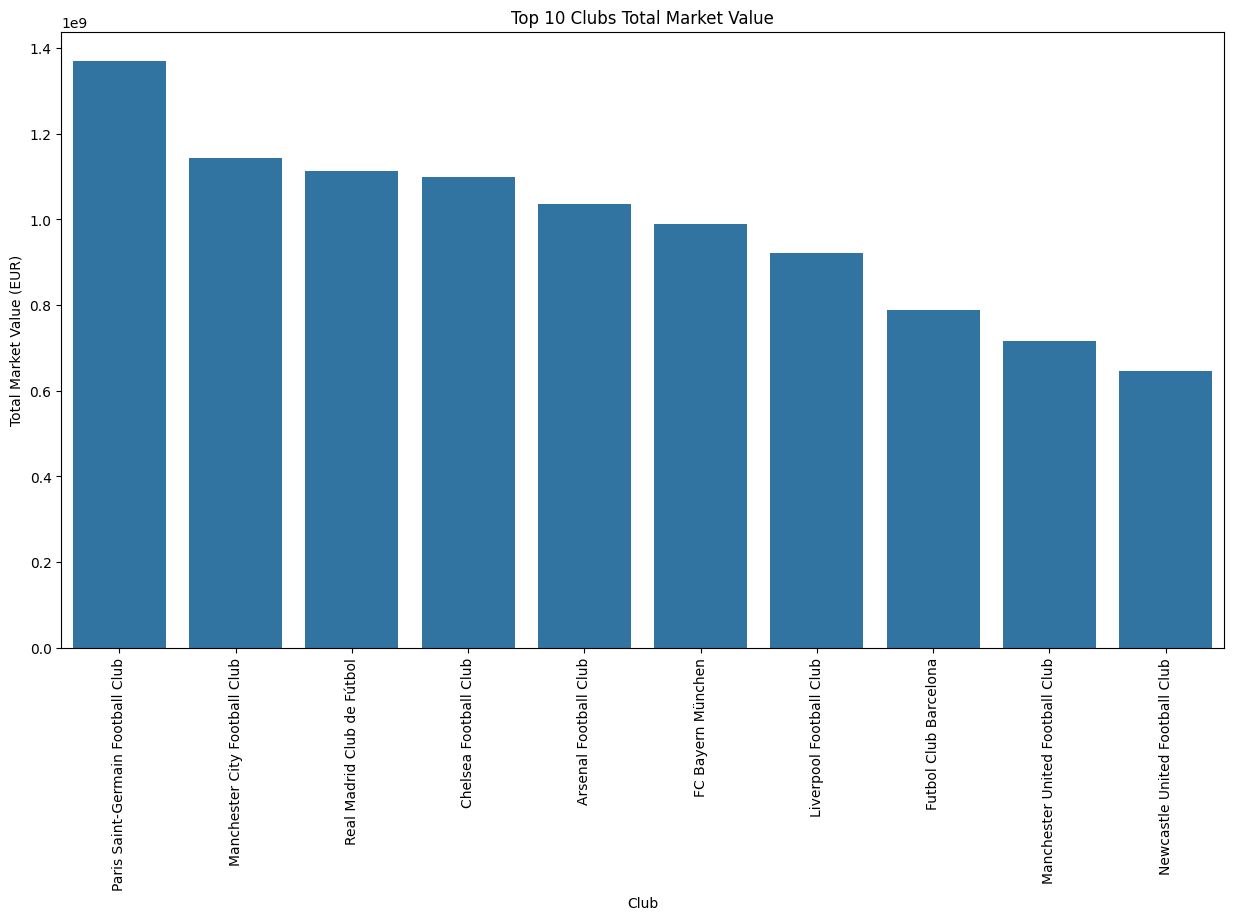

In [52]:
#Which club has the highest market value right now?¶
plt.figure(figsize=(15, 8))
club_value = full_players_info_2023.groupby('current_club_name')['market_value_in_eur'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=club_value.index, y=club_value.values)
plt.title('Top 10 Clubs Total Market Value')
plt.xlabel('Club')
plt.ylabel('Total Market Value (EUR)')
plt.xticks(rotation=90)
plt.show()

In [53]:
club_value.describe()

count    1.000000e+01
mean     9.821300e+08
std      2.201778e+08
min      6.448500e+08
25%      8.213125e+08
50%      1.012400e+09
75%      1.110388e+09
max      1.370000e+09
Name: market_value_in_eur, dtype: float64